# Learning Decision Trees by Inventing Them

**Philosophy:** You won't be taught — you will *discover*. Every step builds on the last. Trust the process.

---

## What you'll need

```python
import math
import random
import matplotlib.pyplot as plt
```

Run the setup cell below before starting.

In [10]:
import math
import random
import matplotlib.pyplot as plt
%matplotlib inline

---

# PART 1: What Is Impurity?

## Exercise 1.1 — Think About Mixing

Imagine a bag of coloured balls — some **Red**, some **Black**.

We want a number that captures how **mixed** the bag is:
- A bag of **all Red** → not mixed at all → impurity = **0**
- A bag of **all Black** → not mixed at all → impurity = **0**
- A bag of **half Red, half Black** → maximally mixed → impurity = **1**


```
impurity(0.5, 0.5)  →  1       # maximally mixed: impurity is 1 
impurity(0, 1)      →  0      # all one colour:  impurity is 0
impurity(1, 0)      →  0
```

> **Important:** Here **impurity = 0** means *completely pure* (easy to classify), and **impurity = 1** means *maximally mixed* (hard to classify). 
**Before coding, answer these questions in the markdown cell below:**

1. If a bag has 80% Red and 20% Black, would its impurity be closer to 0 or 1? Why?
2. What is `impurity(0.9, 0.1)`? Higher or lower than `impurity(0.8, 0.2)`?
3. What mathematical property must the function `impurity(p, q)` have when `p = 1 - q`?
4. Is `impurity(p, q)` the same as `impurity(q, p)`? Why should it be?

**Your answers:**

1. ...
2. ...
3. ...
4. ...

In [ ]:
def impurity (c1, c2) :
    return 1 - (abs(c1 - c2)/(c1 + c2))

In [ ]:
# Answer : 
#1. 
impurity(0.8, 0.2)
# Closer to 0

impurity(0.9, 0.1)
# lower than 0.8, 0.2

## Exercise 1.2 — Invent the Formula

We're going to invent the formula for `impurity(p, q)` where:
- `p` = fraction of Red balls (between 0 and 1)
- `q` = fraction of Black balls (between 0 and 1)
- `p + q = 1` always

**Step-by-step discovery:**

**Step A:** Consider the function $f(p) = p \times (1 - p)$. Fill in the table below by computing it:

| p   | 1-p | p × (1-p) |
|-----|-----|----------|
| 0.0 | 1.0 | ?        |
| 0.2 |     | ?        |
| 0.4 |     | ?        |
| 0.5 |     | ?        |
| 0.6 |     | ?        |
| 0.8 |     | ?        |
| 1.0 |     | ?        |

**Tasks:**

1. Compute the table values in Python and print them.
2. What is the **maximum** value of $p \times (1 - p)$? At what `p` does it occur?
3. What are the **minimum** values? When do they occur?
4. Plot $f(p) = p \times (1 - p)$ for $p \in [0, 1]$ using the helper below.
5. Does this function behave like our desired impurity? Where are its max and min?

**Plotting helper:**
```python
def plot_impurity_candidate(f, title="Candidate impurity function"):
    ps = [i/100 for i in range(101)]
    vals = [f(p) for p in ps]
    plt.figure(figsize=(7, 4))
    plt.plot(ps, vals, 'b-', linewidth=2)
    plt.xlabel('p (fraction of Red)')
    plt.ylabel('impurity')
    plt.title(title)
    plt.grid(True)
    plt.show()
```

In [ ]:

# PLOTTING HELPER — run this cell as-is
def plot_impurity_candidate(f, title="Candidate impurity function"):
    ps = [i/100 for i in range(101)]
    vals = [f(p) for p in ps]
    plt.figure(figsize=(7, 4))
    plt.plot(ps, vals, 'b-', linewidth=2)
    plt.xlabel('p (fraction of Red)')
    plt.ylabel('value')
    plt.title(title)
    plt.grid(True)
    plt.show()

p        1-p            p*(1-p)   
----------------------------------------
0.0  => 1 - p :  1.0 |  p * (1-p) :  0.0
0.2  => 1 - p :  0.8 |  p * (1-p) :  0.16
0.4  => 1 - p :  0.6 |  p * (1-p) :  0.24
0.5  => 1 - p :  0.5 |  p * (1-p) :  0.25
0.6  => 1 - p :  0.4 |  p * (1-p) :  0.24
0.8  => 1 - p :  0.2 |  p * (1-p) :  0.16
1.0  => 1 - p :  0.0 |  p * (1-p) :  0.0
Maximum p * (1-p) =>  0.25
Minimum p * (1-p) =>  0.0
[0.0, 0.0099, 0.0196, 0.029099999999999997, 0.0384, 0.0475, 0.05639999999999999, 0.0651, 0.0736, 0.0819, 0.09000000000000001, 0.0979, 0.1056, 0.1131, 0.12040000000000001, 0.1275, 0.1344, 0.1411, 0.1476, 0.1539, 0.16000000000000003, 0.1659, 0.1716, 0.1771, 0.1824, 0.1875, 0.19240000000000002, 0.1971, 0.2016, 0.20589999999999997, 0.21, 0.21389999999999998, 0.2176, 0.2211, 0.2244, 0.22749999999999998, 0.2304, 0.2331, 0.2356, 0.2379, 0.24, 0.24190000000000003, 0.2436, 0.2451, 0.24640000000000004, 0.24750000000000003, 0.24840000000000004, 0.2491, 0.2496, 0.2499, 0.25, 0.2499, 0

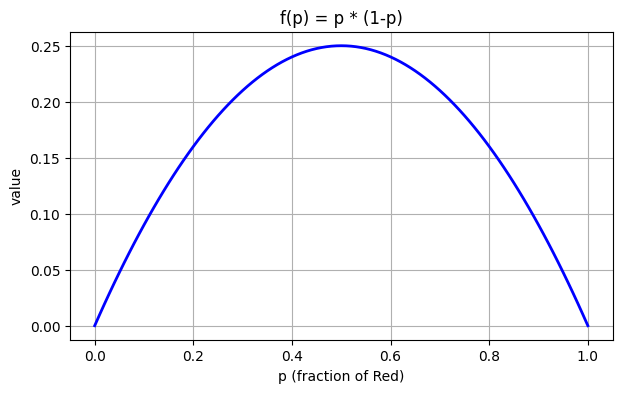

In [16]:
# YOUR CODE HERE
# Step 1: Print the table
print(f"{'p':<8} {'1-p':<14} {'p*(1-p)':<10}")
print("-" * 40)

maximum = 0
minimum = 1e9

for p in [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]:
    maximum = max(maximum, p * (1-p))
    minimum = min(minimum, p * (1-p))
    print(p, " => 1 - p : ", round(1 - p,2), "|  p * (1-p) : ", round(p * (1-p), 2))
    

print("Maximum p * (1-p) => ", maximum)
print("Minimum p * (1-p) => ", minimum)

# Step 2: Plot it
plot_impurity_candidate(lambda p: p * (1 - p), title="f(p) = p * (1-p)")

## Exercise 1.3 — Scale It

From Exercise 1.2, you found that $f(p) = p \times (1-p)$ peaks at $p = 0.5$ with a value of $0.25$.

But we want `impurity(0.5, 0.5) = 1` (max impurity = 1, not 0.25).

Wait — let's re-read the spec:

```
impurity(0.5, 0.5) → 1    ← pure (hard to classify = 1 certainty)
impurity(0, 1)     → 0    ← certain
impurity(1, 0)     → 0    ← certain
```

> Recall: **impurity = 1** means *maximally mixed/uncertain*, and **impurity = 0** means *completely pure/certain*.

So we actually want a function that:
- Returns **1** when `p = 0.5` (most uncertain)
- Returns **0** when `p = 0` or `p = 1` (most certain)

**Your task:**

Take $f(p) = p \times (1 - p)$ and apply a simple transformation to it so that:
- Its maximum (at p=0.5) becomes 1
- Its minimum (at p=0 or p=1) becomes 0


1. Find the transformation mathematically (algebra only, no code yet).
2. Write the resulting formula.
3. Verify by plugging in: $p = 0.5$, $p = 0$, $p = 1$.
4. Write it in Python and plot it.

**Your derivation:**

- Maximum of f(p) = p*(1-p) is ... at p = ...
- Transformation: ...
- Final formula: `impurity(p) = ...`
- Check p=0.5: ...
- Check p=0: ...
- Check p=1: ...

In [47]:
# YOUR CODE HERE
def impurity(p, q):
    """
    Returns the impurity of a set with fraction p of Red and q of Black.
    impurity(0.5, 0.5) should return 1  (most mixed = least certain)
    impurity(1, 0)     should return 0  (all same  = most certain)
    impurity(0, 1)     should return 0
    """
    return 1 - (abs(p - q)/(p + q))


print(impurity(0.9, 0.1)) 
# Verify the spec:
print(impurity(0.5, 0.5))  # should be 1
print(impurity(0, 1))      # should be 0
print(impurity(1, 0))      # should be 0
print(impurity(0.8, 0.2))  # should be between 0 and 1

# Verify ordering:
print(impurity(0.8, 0.2) < impurity(0.7, 0.3))  # should be True
print(impurity(0.7, 0.3) < impurity(0.6, 0.4))  # should be True

0.19999999999999996
1.0
0.0
0.0
0.3999999999999999
True
True


[0.0, 0.020000000000000018, 0.040000000000000036, 0.06000000000000005, 0.08000000000000007, 0.10000000000000009, 0.1200000000000001, 0.14000000000000012, 0.15999999999999992, 0.17999999999999994, 0.19999999999999996, 0.21999999999999997, 0.24, 0.26, 0.28, 0.30000000000000004, 0.32000000000000006, 0.3400000000000001, 0.3599999999999999, 0.3799999999999999, 0.3999999999999999, 0.41999999999999993, 0.43999999999999995, 0.45999999999999996, 0.48, 0.5, 0.52, 0.54, 0.56, 0.5800000000000001, 0.6000000000000001, 0.6200000000000001, 0.6400000000000001, 0.6600000000000001, 0.6800000000000002, 0.7, 0.72, 0.74, 0.76, 0.78, 0.8, 0.8199999999999998, 0.8399999999999999, 0.8599999999999999, 0.8799999999999999, 0.8999999999999999, 0.9199999999999999, 0.94, 0.96, 0.98, 1.0, 0.98, 0.96, 0.94, 0.9199999999999999, 0.8999999999999999, 0.8799999999999999, 0.8600000000000001, 0.8400000000000001, 0.8200000000000001, 0.8, 0.78, 0.76, 0.74, 0.72, 0.7, 0.6799999999999999, 0.6599999999999999, 0.6399999999999999, 0

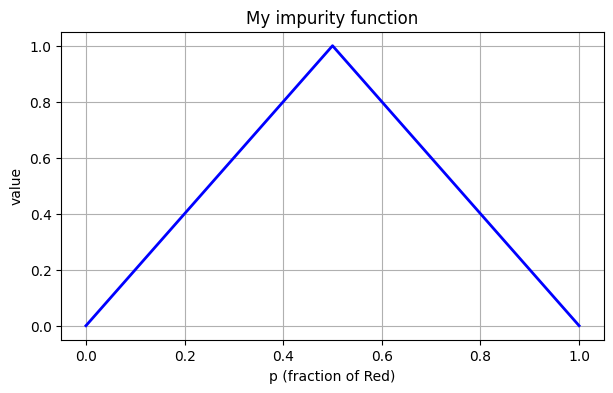

In [18]:
# Plot your impurity function
plot_impurity_candidate(lambda p: impurity(p, 1 - p), title="My impurity function")

## Exercise 1.4 — Explore the Function

Now that you have `impurity(p, q)`, explore it.

**Tasks:**

1. Compute and print the impurity for the following bags. Do the results match your intuition?

| Bag | Contents         | p     | q     |
|-----|-----------------|-------|-------|
| A   | 9 Red, 1 Black  | 0.9   | 0.1   |
| B   | 7 Red, 3 Black  | 0.7   | 0.3   |
| C   | 6 Red, 4 Black  | 0.6   | 0.4   |
| D   | 5 Red, 5 Black  | 0.5   | 0.5   |
| E   | 3 Red, 7 Black  | 0.3   | 0.7   |
| F   | 10 Red, 0 Black | 1.0   | 0.0   |

2. Is bag A more or less certain than bag B? Does `impurity` agree?
3. Is `impurity(0.3, 0.7)` equal to `impurity(0.7, 0.3)`? Why should it be?
4. What is the impurity of a bag with 50 Red, 50 Black, and 50 Green (3 classes)? 
   - Hint: Can you extend your formula? Think about what $p \times (1-p)$ means for each pair of classes.
   - (This is a bonus — don't worry if you can't figure it out now.)

In [19]:
# YOUR CODE HERE
bags = [
    ("A", 0.9, 0.1),
    ("B", 0.7, 0.3),
    ("C", 0.6, 0.4),
    ("D", 0.5, 0.5),
    ("E", 0.3, 0.7),
    ("F", 1.0, 0.0),
]

print(f"{'Bag':<5} {'p':<6} {'q':<6} {'impurity':>10}")
print("-" * 30)
for name, p, q in bags:
    imp = impurity(p, q)
    print(f"{name:<5} {p:<6.1f} {q:<6.1f} {imp:>10.4f}")

Bag   p      q        impurity
------------------------------
A     0.9    0.1        0.2000
B     0.7    0.3        0.6000
C     0.6    0.4        0.8000
D     0.5    0.5        1.0000
E     0.3    0.7        0.6000
F     1.0    0.0        0.0000


In [26]:
p = 1.0
q = 1.0
r = 1.0
print(1 - (abs(p - q - r)/(1 - p + q + r)))

0.5


---

# PART 2: Impurity of a List

## Exercise 2.1 — From Fractions to Lists

So far, `impurity(p, q)` takes fractions directly. But in practice, you have a **list** like:

```python
["R", "B", "B", "R", "R"]
```

You need to compute `p` and `q` from the list yourself.

**Tasks:**

1. For the list `["R", "B", "B", "R", "R"]`, manually compute:
   - Count of "R"
   - Count of "B"
   - Total count
   - `p` (fraction of R)
   - `q` (fraction of B)

2. Write a function `list_impurity(items)` that:
   - Takes a list of "R" and "B" strings
   - Computes `p` and `q`
   - Returns `impurity(p, q)`
   - **Edge case:** What should it return for an empty list `[]`? Decide and document your choice.

3. Test your function:
   ```python
   list_impurity(["R", "B", "B", "R", "R"])   # what do you expect?
   list_impurity(["R", "R", "R", "R"])         # all same → what value?
   list_impurity(["B", "B", "B", "B"])         # all same → what value?
   list_impurity(["R", "B"])                   # exactly half → what value?
   list_impurity([])                           # empty → your decision
   ```

4. Try these additional lists and rank them by impurity (most mixed to least mixed):
   ```python
   list_A = ["R", "R", "R", "R", "R", "R", "R", "R", "B", "B"]
   list_B = ["R", "R", "R", "R", "R", "B", "B", "B", "B", "B"]
   list_C = ["R", "R", "R", "R", "R", "R", "R", "B", "B", "B"]
   ```

In [96]:
# YOUR CODE HERE
def list_impurity(items):
    """
    Computes the impurity of a list of "R" and "B" elements.
    Returns a value between 0 (pure/certain) and 1 (maximally mixed).
    """
    length = len(items)
    
    # impurity is 0 if []
    if (length == 0) :
        return 0

    r_count = 0
    b_count = 0


    for i in items :
        if ( i == 'R' or i == 'F') :
            r_count += 1
        elif (i == 'B' or i == 'M'):
            b_count += 1
    
   
    return impurity(r_count/length , b_count/length)


# Test cases
test_cases = [
    ["R", "B", "B", "R", "R"],
    ["R", "R", "R", "R"],
    ["B", "B", "B", "B"],
    ["R", "B"],
    [],
]

for lst in test_cases:
    print(f"{str(lst):<40}  impurity = {list_impurity(lst):.4f}")

['R', 'B', 'B', 'R', 'R']                 impurity = 0.8000
['R', 'R', 'R', 'R']                      impurity = 0.0000
['B', 'B', 'B', 'B']                      impurity = 0.0000
['R', 'B']                                impurity = 1.0000
[]                                        impurity = 0.0000


In [31]:
# Ranking exercise
list_A = ["R", "R", "R", "R", "R", "R", "R", "R", "B", "B"]
list_B = ["R", "R", "R", "R", "R", "B", "B", "B", "B", "B"]
list_C = ["R", "R", "R", "R", "R", "R", "R", "B", "B", "B"]

for name, lst in [("A", list_A), ("B", list_B), ("C", list_C)]:
    print(f"List {name}: impurity = {list_impurity(lst):.4f}")

# Which is most mixed? Least mixed?

List A: impurity = 0.4000
List B: impurity = 1.0000
List C: impurity = 0.6000


## Exercise 2.2 — Weighted Impurity of Two Groups

When we split a list into two parts, we get two separate impurity values — one for each part.

But how do we combine them into one number?

**Think about it:** If one group has 100 items and another has 2 items, should they count equally?

**Your task:**

1. Invent a formula for the **total impurity** of two groups, `left` and `right`, that accounts for their sizes.
   - What should happen if one group is empty?
   - What should happen if both groups are identical?
   - Hint: think about weighted average.

2. Write a function `total_impurity(left, right)` that takes two lists and returns a single number.

3. Test it:
   ```python
   total_impurity(["R", "R", "R"], ["B", "B", "B"])  # perfectly separated
   total_impurity(["R", "B", "R"], ["B", "R", "B"])  # each group is mixed
   total_impurity(["R", "R", "R", "R", "R", "R", "R", "R", "R", "B"], ["B"])  # unequal sizes
   ```

4. Reflection: For the last test case, the right group has 1 item (`["B"]`) so it's pure (impurity = 0). But it only has 1 item out of 11 total. Does your formula give it less weight? It should.

In [80]:
# YOUR CODE HERE
def total_impurity(left, right):
    """
    Returns the weighted total impurity of two groups.
    Each group's impurity is weighted by its size relative to the combined total.
    """

    l_len = len(left)
    r_len = len(right)
    
    left_impurity = round(list_impurity(left), 2)
    right_impurity = round(list_impurity(right), 2)


    return ((l_len * left_impurity ) + (r_len * right_impurity )) / (l_len + r_len)


# Test cases
print(total_impurity(["R", "R", "R"], ["B", "B", "B"]))  # perfectly separated → expect high certainty
print(total_impurity(["R", "B", "R"], ["B", "R", "B"]))  # both mixed
print(total_impurity(["R"]*9 + ["B"], ["B"]))            # unequal sizes

print(total_impurity(['F', 'F', 'F', 'F', 'M', 'F', 'M', 'M'], ['F', 'M', 'M', 'M', 'M', 'M', 'F', 'M', 'M', 'M', 'M', 'M']))

0.0
0.67
0.18181818181818182
0.0


---

# PART 3: Finding the Best Split

## Exercise 3.1 — Splitting a List at a Position

You are given an ordered list:

```python
items = ["R", "B", "B", "R", "R"]
```

You can **split** it at position `k` (0-indexed), meaning:
- **Left part:** `items[:k]` — the first `k` items
- **Right part:** `items[k:]` — the remaining items

For example, splitting at position `k=2`:
- Left: `["R", "B"]`
- Right: `["B", "R", "R"]`

**Tasks:**

1. For `items = ["R", "B", "B", "R", "R"]`, print the left and right parts for **every possible split position** `k = 1, 2, 3, 4`.
   - (Why not `k=0` or `k=5`? What would those give?)

2. For each split position, compute `total_impurity(left, right)`. Print all values.

3. Which split position gives the **minimum** total impurity? 
   - What are the left and right groups at that position?
   - Does that split make intuitive sense?

In [81]:
# YOUR CODE HERE
items = ["R", "B", "B", "R", "R"]

print(f"{'k':<5} {'left':<25} {'right':<25} {'total impurity':>15}")
print("-" * 70)

for k in range(1, len(items)):
    left = items[:k]
    right = items[k:]
    imp = total_impurity(left, right)
    print(f"{k:<5} {str(left):<25} {str(right):<25} {imp:>15.4f}")

k     left                      right                      total impurity
----------------------------------------------------------------------
1     ['R']                     ['B', 'B', 'R', 'R']               0.8000
2     ['R', 'B']                ['B', 'R', 'R']                    0.8020
3     ['R', 'B', 'B']           ['R', 'R']                         0.4020
4     ['R', 'B', 'B', 'R']      ['R']                              0.8000


## Exercise 3.2 — The Best Split Function

Now automate it: write a function `find_best_split_position(items)` that:
- Tries every possible split position `k = 1` to `len(items) - 1`
- Computes `total_impurity` at each position
- Returns the position `k` that gives the **minimum** total impurity

**Tasks:**

1. Implement `find_best_split_position(items)`. It should return the best `k` and the minimum total impurity.

2. Test it on these lists:
   ```python
   ["R", "B", "B", "R", "R"]
   ["R", "R", "R", "B", "B", "B"]
   ["B", "R", "B", "R", "B", "R"]
   ["R", "R", "R", "R", "B"]
   ```

3. For `["R", "R", "R", "B", "B", "B"]`, the answer should be obvious from visual inspection. Does your function agree?

4. For `["B", "R", "B", "R", "B", "R"]` (perfectly alternating), what split position does it find? Are there multiple "tied" positions? How does your function handle ties?

In [55]:
# YOUR CODE HERE
def find_best_split_position(items):
    """
    Finds the split position k that minimises total_impurity(items[:k], items[k:]).
    Returns (best_k, min_impurity).
    """
    minimum = 1e9
    index = 0
    for k in range(1, len(items)):
        left = items[:k]
        right = items[k:]
        imp = total_impurity(left, right)
        if (minimum > imp) :
            minimum = imp
            index = k
    return index, minimum


# Test
test_lists = [
    ["R", "B", "B", "R", "R"],
    ["R", "R", "R", "B", "B", "B"],
    ["B", "R", "B", "R", "B", "R"],
    ["R", "R", "R", "R", "B"],
]

for lst in test_lists:
    best_k, min_imp = find_best_split_position(lst)
    print(f"List: {lst}")
    print(f"  Best k={best_k}: left={lst[:best_k]}, right={lst[best_k:]}")
    print(f"  Min impurity: {min_imp:.4f}")
    print()

List: ['R', 'B', 'B', 'R', 'R']
  Best k=3: left=['R', 'B', 'B'], right=['R', 'R']
  Min impurity: 0.4020

List: ['R', 'R', 'R', 'B', 'B', 'B']
  Best k=3: left=['R', 'R', 'R'], right=['B', 'B', 'B']
  Min impurity: 0.0000

List: ['B', 'R', 'B', 'R', 'B', 'R']
  Best k=1: left=['B'], right=['R', 'B', 'R', 'B', 'R']
  Min impurity: 0.6667

List: ['R', 'R', 'R', 'R', 'B']
  Best k=4: left=['R', 'R', 'R', 'R'], right=['B']
  Min impurity: 0.0000



## Exercise 3.3 — Visualise the Split Scores

Use the plotting helper below to visualise how total impurity changes at each split position.

```python
def plot_split_scores(items, title=None):
    """
    Plots total_impurity vs split position k for a given list.
    Marks the best (minimum impurity) position.
    """
    ks = list(range(1, len(items)))
    scores = [total_impurity(items[:k], items[k:]) for k in ks]
    best_k = ks[scores.index(min(scores))]

    plt.figure(figsize=(8, 4))
    plt.plot(ks, scores, 'b-o')
    plt.axvline(x=best_k, color='red', linestyle='--', label=f'best k={best_k}')
    plt.xlabel('Split position k')
    plt.ylabel('Total impurity')
    plt.title(title or f'Split scores for {items}')
    plt.legend()
    plt.grid(True)
    plt.show()
```

**Tasks:**

1. Run `plot_split_scores` on all four test lists from Exercise 3.2.
2. For `["R", "R", "R", "B", "B", "B"]`: is the minimum sharp or flat? Why?
3. For `["B", "R", "B", "R", "B", "R"]`: what does the plot look like? Is there a clear winner?

In [56]:
# PLOTTING HELPER — run this cell as-is
def plot_split_scores(items, title=None):
    ks = list(range(1, len(items)))
    scores = [total_impurity(items[:k], items[k:]) for k in ks]
    best_k = ks[scores.index(min(scores))]
    plt.figure(figsize=(8, 4))
    plt.plot(ks, scores, 'b-o')
    plt.axvline(x=best_k, color='red', linestyle='--', label=f'best k={best_k}')
    plt.xlabel('Split position k')
    plt.ylabel('Total impurity')
    plt.title(title or f'Split scores for {items}')
    plt.legend()
    plt.grid(True)
    plt.show()

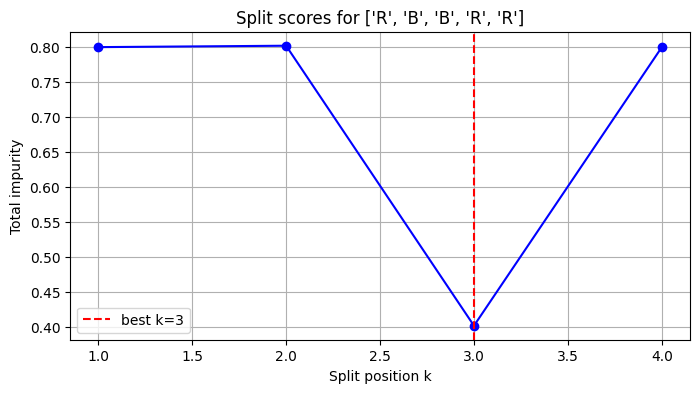

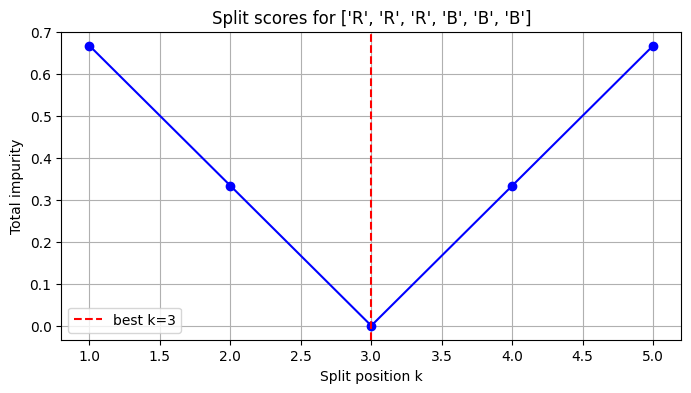

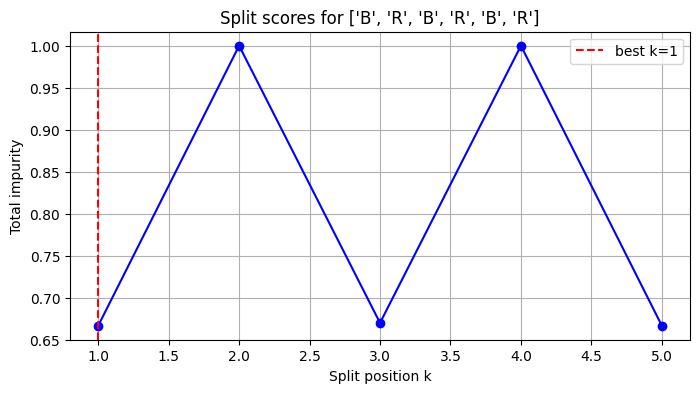

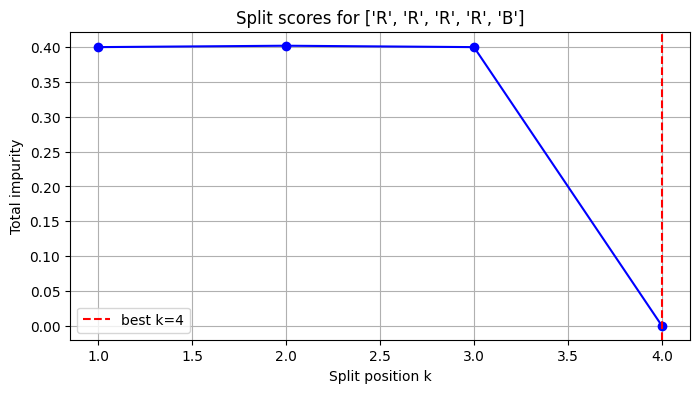

In [57]:
# YOUR CODE HERE — plot all four lists
for lst in test_lists:
    plot_split_scores(lst)

---

# PART 4: Splitting Real Data — Height & Gender

## Exercise 4.1 — Meet the Dataset

You are given a dataset of students in a class. Each student has a **height** (in cm) and a **gender** ("M" or "F").

Run the cell below to load the data.

In [82]:
# DATASET — run this cell as-is
random.seed(42)

heights = [158, 162, 165, 167, 168, 170, 171, 172, 174, 175,
           176, 178, 179, 180, 181, 182, 183, 185, 187, 190]
genders = ["F",  "F",  "F",  "F",  "M",  "F",  "M",  "M",  "F",  "M",
           "M",  "M",  "M",  "M",  "F",  "M",  "M",  "M",  "M",  "M"]

print("Height  Gender")
print("-" * 16)
for h, g in zip(heights, genders):
    print(f"{h:<8} {g}")

Height  Gender
----------------
158      F
162      F
165      F
167      F
168      M
170      F
171      M
172      M
174      F
175      M
176      M
178      M
179      M
180      M
181      F
182      M
183      M
185      M
187      M
190      M


**Before coding, answer these questions:**

1. Just by looking at the data, at roughly what height does gender start being predominantly Male?
2. If you had to draw a single horizontal line through the data to separate M from F as cleanly as possible, where would you draw it?
3. Is a perfect separation possible? Why or why not?

**Your answers:**

1. ...
2. ...
3. ...

## Exercise 4.2 — Visualise the Data

Run the plotting helper below to see the data.

In [59]:
# PLOTTING HELPER — run this cell as-is
def plot_height_gender(heights, genders, split_height=None, title="Height vs Gender"):
    """
    Scatter plot of height vs gender.
    Optionally draws a vertical split line at split_height.
    """
    colors = {"M": "blue", "F": "red"}
    y_jitter = {"M": 1, "F": 0}
    plt.figure(figsize=(10, 3))
    for h, g in zip(heights, genders):
        plt.scatter(h, y_jitter[g], color=colors[g], s=80, zorder=5)
        plt.text(h, y_jitter[g] + 0.05, g, ha='center', fontsize=8)
    if split_height is not None:
        plt.axvline(x=split_height, color='green', linestyle='--', linewidth=2,
                    label=f'split at {split_height}')
        plt.legend()
    plt.yticks([0, 1], ["F", "M"])
    plt.xlabel("Height (cm)")
    plt.title(title)
    plt.grid(axis='x')
    plt.tight_layout()
    plt.show()

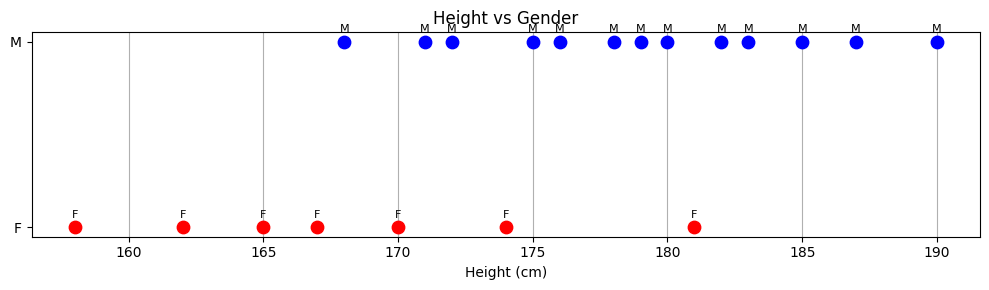

In [60]:
# Plot the data
plot_height_gender(heights, genders)

## Exercise 4.3 — Split by Height Threshold

Now the key idea: instead of splitting at a *position* in a list, we split at a **threshold value** in a feature.

For a given threshold `t`:
- **Left group:** all rows where `height <= t`
- **Right group:** all rows where `height > t`

We compute the genders in each group, then calculate `total_impurity`.

**Tasks:**

1. Write a function `split_by_threshold(heights, genders, t)` that:
   - Splits the data at threshold `t`
   - Returns `(left_genders, right_genders)` where each is a list of gender labels

2. Test it: `split_by_threshold(heights, genders, 172)` should return:
   - left: genders of everyone with height ≤ 172
   - right: genders of everyone with height > 172

3. For the thresholds below, compute and print `total_impurity(left, right)`. Notice the pattern.

   ```
   t = 160, 165, 170, 172, 175, 178, 182, 185, 188
   ```

4. Which threshold gives the lowest total impurity? Verify visually using `plot_height_gender` with `split_height=t`.

In [99]:
# YOUR CODE HERE
def split_by_threshold(heights, genders, t):
    """
    Splits the dataset at threshold t on height.
    Returns (left_genders, right_genders) where:
      left_genders  = genders where height <= t
      right_genders = genders where height > t
    """
    left = []
    right = []
    for h, g in zip(heights, genders) :
        if (h <= t) :
           left.append(g)
        else :
            right.append(g)
    
    return left, right



# Test manually
left, right = split_by_threshold(heights, genders, 172)
print("Left (height <= 172):", left)
print("Right (height > 172):", right)
print("Total impurity:", total_impurity(left, right))

Left (height <= 172): ['F', 'F', 'F', 'F', 'M', 'F', 'M', 'M']
Right (height > 172): ['F', 'M', 'M', 'M', 'M', 'M', 'F', 'M', 'M', 'M', 'M', 'M']
Total impurity: 0.49800000000000005


In [100]:
# Test multiple thresholds
thresholds = [160, 165, 170, 172, 175, 178, 182, 185, 188]

print(f"{'Threshold':<12} {'Left size':<12} {'Right size':<12} {'Total impurity':>15}")
print("-" * 55)

for t in thresholds:
    left, right = split_by_threshold(heights, genders, t)
    imp = total_impurity(left, right)
    print(f"{t:<12} {len(left):<12} {len(right):<12} {imp:>15.4f}")

Threshold    Left size    Right size    Total impurity
-------------------------------------------------------
160          1            19                    0.5985
165          3            17                    0.3995
170          6            14                    0.3020
172          8            12                    0.4980
175          10           10                    0.5000
178          12           8                     0.7000
182          16           4                     0.7040
185          18           2                     0.7020
188          19           1                     0.7030


## Exercise 4.4 — Find the Best Threshold Automatically

Instead of manually trying thresholds, automate it.

**Key insight:** You only need to try thresholds at the **unique values in your data** (or midpoints between consecutive values). Why? Because splitting at 173.5 vs 174 makes no difference if there's no data point between them.

**Tasks:**

1. Write `find_best_threshold(heights, genders)` that:
   - Tries every unique height value as a threshold
   - Computes `total_impurity` for each
   - Returns the threshold with minimum total impurity, and that minimum impurity value

2. Run it and print the result. Does it match your manual inspection?

3. Visualise the best threshold using `plot_height_gender(heights, genders, split_height=best_t)`.

4. **Reflection:** What are the genders in the left and right groups at the best threshold? Is the split clean?

Best threshold: height <= 170
Minimum total impurity: 0.3020
Left group:  ['F', 'F', 'F', 'F', 'M', 'F']
Right group: ['M', 'M', 'F', 'M', 'M', 'M', 'M', 'M', 'F', 'M', 'M', 'M', 'M', 'M']


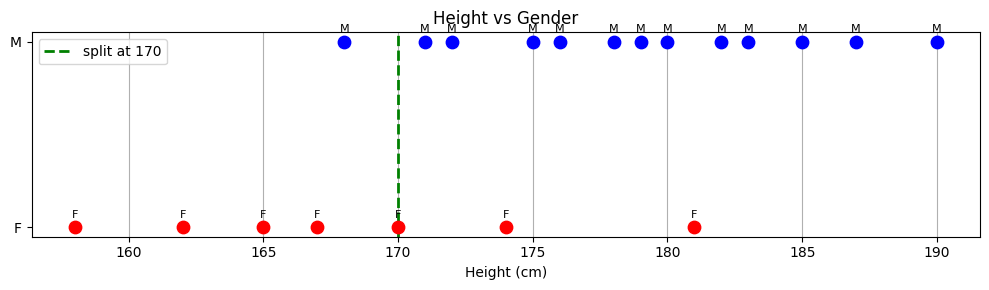

In [101]:
# YOUR CODE HERE
def find_best_threshold(heights, genders):
    """
    Finds the height threshold that minimises total_impurity.
    Returns (best_threshold, min_impurity).
    """
    best_t=0
    best_imp = 1e9
    for t in heights :
        left, right = split_by_threshold(heights, genders, t)
        imp = total_impurity(left, right)
        if (imp < best_imp) :
            best_imp = imp
            best_t = t
    
    return best_t, best_imp



best_t, best_imp = find_best_threshold(heights, genders)
print(f"Best threshold: height <= {best_t}")
print(f"Minimum total impurity: {best_imp:.4f}")

left, right = split_by_threshold(heights, genders, best_t)
print(f"Left group:  {left}")
print(f"Right group: {right}")

plot_height_gender(heights, genders, split_height=best_t)

## Exercise 4.5 — Plot Impurity vs Threshold

Use the plotting helper below to visualise how impurity changes as the threshold varies.

In [97]:
# PLOTTING HELPER — run this cell as-is
def plot_threshold_scores(heights, genders, title="Impurity vs Threshold"):
    """
    Plots total impurity for each unique height threshold.
    """
    unique_heights = sorted(set(heights))
    scores = []
    for t in unique_heights:
        left = [g for h, g in zip(heights, genders) if h <= t]
        right = [g for h, g in zip(heights, genders) if h > t]
        if left and right:
            scores.append((t, total_impurity(left, right)))

    ts, imps = zip(*scores)
    best_t = ts[imps.index(min(imps))]

    plt.figure(figsize=(9, 4))
    plt.plot(ts, imps, 'b-o')
    plt.axvline(x=best_t, color='red', linestyle='--', label=f'best t={best_t}')
    plt.xlabel('Threshold (height cm)')
    plt.ylabel('Total impurity')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

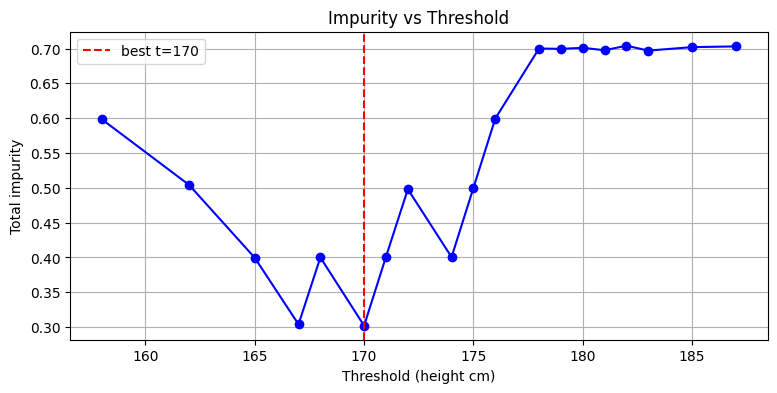

In [98]:
# YOUR CODE HERE — run the plot
plot_threshold_scores(heights, genders)

---

# PART 5: A Decision Node — The Job Offer

## Exercise 5.1 — What Is a Decision Tree Node?

Before we build a full tree from data, let's understand the structure of a decision tree by **constructing one by hand**.

A decision tree is made of **nodes**. There are two kinds:

- **Boundary node:** Has a rule — "if feature X ≤ value, go left; else go right." Has two children.
- **Leaf node:** Has a final answer — just `True` (YES) or `False` (NO). No children.

Here is a tree for deciding whether to accept a job offer:

```
Is salary > 1000?
├── NO  → Reject the offer
└── YES → Is distance <= 40?
           ├── YES → Accept the offer
           └── NO  → Reject the offer
```

**Before coding, answer these questions:**

1. If a job pays 800 and is 20km away — what does the tree say?
2. If a job pays 1200 and is 30km away — what does the tree say?
3. If a job pays 1500 and is 60km away — what does the tree say?
4. If a job pays 1000 exactly — which branch do you take? (Careful: the rule is `salary > 1000`.)

Write your answers below before coding.

**Your answers:**

1. salary=800, distance=20 → ...
2. salary=1200, distance=30 → ...
3. salary=1500, distance=60 → ...
4. salary=1000, distance=any → ...

## Exercise 5.2 — Build the `DecisionTreeNode` Class

Design a class `DecisionTreeNode` that can be either a **boundary node** or a **leaf node**.

**Requirements:**

- A **leaf node** stores a boolean `decision` (`True` = YES, `False` = NO).
- A **boundary node** stores:
  - `boundary` — the feature name (a string, e.g. `"salary"`)
  - `boundary_value` — the threshold (a number)
  - `left` — the child node for when `feature <= boundary_value`
  - `right` — the child node for when `feature > boundary_value`
- A method `check(features)` that:
  - Takes a dict like `{"salary": 1200, "distance": 30}`
  - Traverses the tree
  - Returns the leaf's boolean `decision`

**Also create two helper functions:**
- `YES()` — returns a leaf node with decision `True`
- `NO()` — returns a leaf node with decision `False`

**Hint for the class structure:**
```python
class DecisionTreeNode:
    def __init__(self, ...):
        # your attributes here
        pass

    def check(self, features):
        # if leaf: return decision
        # if boundary: go left or right depending on features[self.boundary]
        pass
```

**Tasks:**

1. Implement `DecisionTreeNode`, `YES()`, and `NO()`.
2. Build the job offer tree manually:
   ```
   Is salary <= 1000? → NO()
   Else: Is distance <= 40? → YES() else NO()
   ```
3. Test it against your answers from Exercise 5.1.

In [148]:
# YOUR CODE HERE
class DecisionTreeNode:
    def __init__(self, decision=None, boundary=None, boundary_value=None, left=None, right=None):
        """
        A node in a decision tree.
        
        If decision is not None: this is a leaf node.
        Otherwise: this is a boundary node with boundary, boundary_value, left, right.
        """
        self.decision = decision
        self.boundary = boundary
        self.boundary_value = boundary_value
        self.left = left
        self.right = right

    def check(self, features):
        """
        Traverses the tree and returns the leaf's boolean decision.
        features: dict of {feature_name: value}
        Rule: go LEFT if features[boundary] <= boundary_value, else go RIGHT.
        """

        if self.decision is not None:
            return self.decision
        
        value = features[self.boundary]

        if value <= self.boundary_value:
            return self.left.check(features)
        else:
            return self.right.check(features)


def YES():
    return DecisionTreeNode(decision=True)

def NO():
    return DecisionTreeNode(decision=False)

In [149]:
# Build the job offer tree
# Tree:
#   salary <= 1000 → NO
#   salary > 1000:
#       distance <= 40 → YES
#       distance > 40  → NO

job_tree = DecisionTreeNode(
    boundary="salary",
    boundary_value=1000,
    left=NO(),
    right=DecisionTreeNode(
        boundary="distance",
        boundary_value=40,
        left=YES(),
        right=NO()
    )
)

# Test the four cases from Exercise 5.1
test_jobs = [
    {"salary": 800,  "distance": 20, "expected": False},
    {"salary": 1200, "distance": 30, "expected": True},
    {"salary": 1500, "distance": 60, "expected": False},
    {"salary": 1000, "distance": 15, "expected": False},
]

print(f"{'Salary':<10} {'Distance':<12} {'Result':<10} {'Expected':<10} {'Match'}")
print("-" * 55)
for job in test_jobs:
    result = job_tree.check(job)
    match = "✓" if result == job["expected"] else "✗"
    print(f"{job['salary']:<10} {job['distance']:<12} {str(result):<10} {str(job['expected']):<10} {match}")

Salary     Distance     Result     Expected   Match
-------------------------------------------------------
800        20           False      False      ✓
1200       30           True       True       ✓
1500       60           False      False      ✓
1000       15           False      False      ✓


## Exercise 5.3 — A Bigger Tree

Now build a more complex tree by hand. This tree has 3 levels:

```
Is salary <= 1000?
├── YES → NO (reject)
└── NO (salary > 1000):
    Is distance <= 40?
    ├── YES (close enough):
    │   Is coffee == 1?         ← 1 means "office has free coffee"
    │   ├── YES → YES (accept)
    │   └── NO  → NO (reject)
    └── NO (too far) → NO (reject)
```

**Tasks:**

1. Build this tree using `DecisionTreeNode`, `YES()`, and `NO()`.
2. Test with these job offers:

| salary | distance | coffee | Expected |
|--------|----------|--------|----------|
| 1200   | 30       | 1      | YES      |
| 1200   | 30       | 0      | NO       |
| 1200   | 60       | 1      | NO       |
| 900    | 10       | 1      | NO       |

3. Extend the tree by adding one more rule of your own. Document it in a markdown cell.

In [153]:
# YOUR CODE HERE — build the 3-level tree
job_tree_v2 = DecisionTreeNode(
    boundary="salary",
    boundary_value=1000,
    left = NO(),
    right = DecisionTreeNode(
        boundary="distance",
        boundary_value=40,
        left = DecisionTreeNode(
            boundary="coffee",
            boundary_value=0,
            left = NO(),
            right = YES()
        ),
        right = NO()
    )
)

# Test cases
test_v2 = [
    {"salary": 1200, "distance": 30, "coffee": 1, "expected": True},
    {"salary": 1200, "distance": 30, "coffee": 0, "expected": False},
    {"salary": 1200, "distance": 60, "coffee": 1, "expected": False},
    {"salary": 900,  "distance": 10, "coffee": 1, "expected": False},
]

for job in test_v2:
    result = job_tree_v2.check(job)
    match = "✓" if result == job["expected"] else "✗"
    print(f"salary={job['salary']}, distance={job['distance']}, coffee={job['coffee']}  →  {result}  {match}")

salary=1200, distance=30, coffee=1  →  True  ✓
salary=1200, distance=30, coffee=0  →  False  ✓
salary=1200, distance=60, coffee=1  →  False  ✓
salary=900, distance=10, coffee=1  →  False  ✓


---

# PART 6: Multiple Features — Finding the Best Split

## Exercise 6.1 — Add a Second Feature: Weight

Now the dataset has **two features**: height and weight. We want to find which feature and which threshold gives the best split.

Run the cell below to load the extended dataset.

In [195]:
# EXTENDED DATASET — run this cell as-is
data = [
    {"height": 158, "weight": 52, "gender": "F"},
    {"height": 162, "weight": 55, "gender": "F"},
    {"height": 165, "weight": 58, "gender": "F"},
    {"height": 167, "weight": 61, "gender": "F"},
    {"height": 168, "weight": 70, "gender": "M"},
    {"height": 170, "weight": 60, "gender": "F"},
    {"height": 171, "weight": 73, "gender": "M"},
    {"height": 172, "weight": 75, "gender": "M"},
    {"height": 174, "weight": 63, "gender": "F"},
    {"height": 175, "weight": 78, "gender": "M"},
    {"height": 176, "weight": 80, "gender": "M"},
    {"height": 178, "weight": 82, "gender": "M"},
    {"height": 179, "weight": 84, "gender": "M"},
    {"height": 180, "weight": 85, "gender": "M"},
    {"height": 181, "weight": 66, "gender": "F"},
    {"height": 182, "weight": 88, "gender": "M"},
    {"height": 183, "weight": 90, "gender": "M"},
    {"height": 185, "weight": 92, "gender": "M"},
    {"height": 187, "weight": 95, "gender": "M"},
    {"height": 190, "weight": 98, "gender": "M"},
]

print(f"{'Height':<8} {'Weight':<8} {'Gender'}")
print("-" * 24)
for row in data:
    print(f"{row['height']:<8} {row['weight']:<8} {row['gender']}")

Height   Weight   Gender
------------------------
158      52       F
162      55       F
165      58       F
167      61       F
168      70       M
170      60       F
171      73       M
172      75       M
174      63       F
175      78       M
176      80       M
178      82       M
179      84       M
180      85       M
181      66       F
182      88       M
183      90       M
185      92       M
187      95       M
190      98       M


## Exercise 6.2 — Find the Best Feature and Threshold

**The question:** Should we split on **height** or **weight**, and at what value?

**Your task:**

Write a function `find_decision_boundary(data, features, label)` that:
- Takes a list of dicts (`data`), a list of feature names to consider (`features`), and the label column name (`label`)
- For **each feature** in `features`:
  - Tries every unique value of that feature as a threshold
  - Computes `total_impurity` for that split
- Returns the **best feature name**, the **best threshold**, and the **minimum impurity**

**Step-by-step hints:**
1. Extract all unique values for a feature: `sorted(set(row[feature] for row in data))`
2. For each threshold `t`, the left group is `[row[label] for row in data if row[feature] <= t]`
3. Track the best (feature, threshold, impurity) triple as you loop

**Tasks:**

1. Implement `find_decision_boundary`.
2. Run it on the dataset with `features=["height", "weight"]` and `label="gender"`.
3. Print the result. Which feature won? At what threshold?
4. Does this match what you expected from looking at the data?

In [196]:
# YOUR CODE HERE
def find_decision_boundary(data, features, label):
    """
    Finds the best (feature, threshold) split across all given features.
    Returns (best_feature, best_threshold, min_impurity).
    """

    feature = ""

    best_t = 0
    best_imp = 1e9

    label_arr = []

    for val in data :
        label_arr.append(val[label])

    for feat in features :
        test_data = []

        for val in data :
            test_data.append(val[feat])
        
        _t, _imp = find_best_threshold(test_data, label_arr)

        if (_imp < best_imp) :
            best_imp = _imp
            best_t = _t
            feature = feat

    
    return feature, best_t, best_imp


best_feat, best_t, best_imp = find_decision_boundary(data, ["height", "weight"], "gender")
print(f"Best split: {best_feat} <= {best_t}")
print(f"Minimum total impurity: {best_imp:.4f}")

# What are the two groups?
left_group = [row["gender"] for row in data if row[best_feat] <= best_t]
right_group = [row["gender"] for row in data if row[best_feat] > best_t]
print(f"Left  ({best_feat} <= {best_t}): {left_group}")
print(f"Right ({best_feat} >  {best_t}): {right_group}")

Best split: weight <= 66
Minimum total impurity: 0.0000
Left  (weight <= 66): ['F', 'F', 'F', 'F', 'F', 'F', 'F']
Right (weight >  66): ['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M']


## Exercise 6.3 — Visualise Both Features

Use the helper below to visualise both the height split and the weight split.

In [114]:
# PLOTTING HELPER — run this cell as-is
def plot_feature_split(data, feature, label, split_value=None, title=None):
    """
    Plots a feature vs label. Optionally marks a split threshold.
    """
    color_map = {"M": "blue", "F": "red"}
    y_map = {"M": 1, "F": 0}

    plt.figure(figsize=(10, 3))
    for row in data:
        x = row[feature]
        y = y_map[row[label]]
        c = color_map[row[label]]
        plt.scatter(x, y, color=c, s=80, zorder=5)
        plt.text(x, y + 0.06, row[label], ha='center', fontsize=8)

    if split_value is not None:
        plt.axvline(x=split_value, color='green', linestyle='--', linewidth=2,
                    label=f'split at {split_value}')
        plt.legend()

    plt.yticks([0, 1], ["F", "M"])
    plt.xlabel(feature)
    plt.title(title or f"{feature} vs {label}")
    plt.grid(axis='x')
    plt.tight_layout()
    plt.show()

Best height split: height <= 170, impurity = 0.3020
Best weight split: weight <= 66, impurity = 0.0000


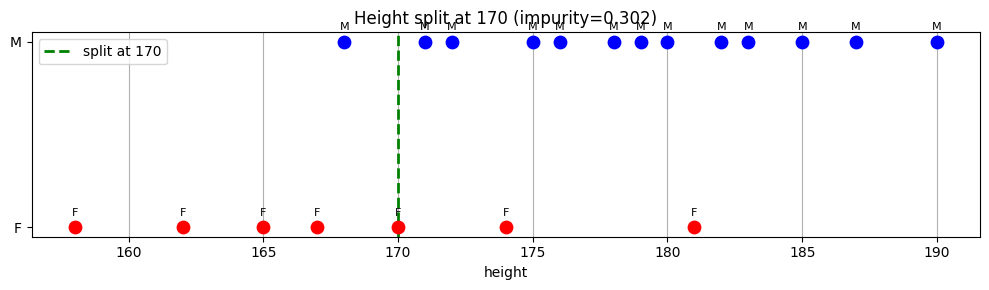

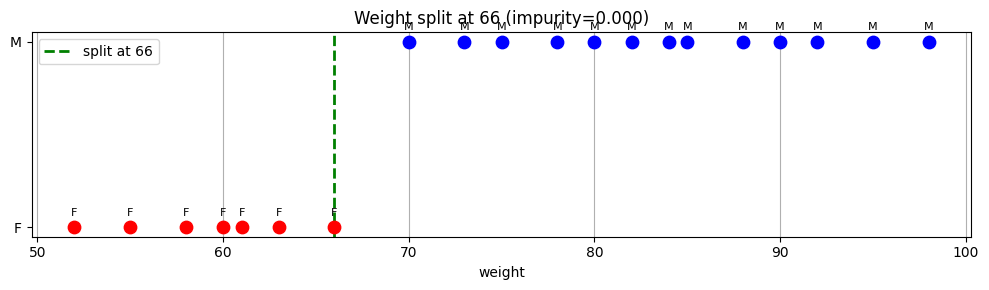

In [115]:
# YOUR CODE HERE — plot height split and weight split
# Use find_decision_boundary first on each feature separately

best_h, best_ht, imp_h = find_decision_boundary(data, ["height"], "gender")
best_w, best_wt, imp_w = find_decision_boundary(data, ["weight"], "gender")

print(f"Best height split: height <= {best_ht}, impurity = {imp_h:.4f}")
print(f"Best weight split: weight <= {best_wt}, impurity = {imp_w:.4f}")

plot_feature_split(data, "height", "gender", split_value=best_ht, title=f"Height split at {best_ht} (impurity={imp_h:.3f})")
plot_feature_split(data, "weight", "gender", split_value=best_wt, title=f"Weight split at {best_wt} (impurity={imp_w:.3f})")

---

# PART 7: Growing the Tree — Recursive Splitting

## Exercise 7.1 — What Happens After the First Split?

After the first split, you have two groups. Each group may still be impure (mixed). 

The idea: **repeat the splitting** on each group independently, until each group is pure (impurity = 1) or has only 1 element.

**Before coding, trace through manually:**

Using the height-only dataset from Part 4:
```python
heights = [158, 162, 165, 167, 168, 170, 171, 172, 174, 175,
           176, 178, 179, 180, 181, 182, 183, 185, 187, 190]
genders = ["F",  "F",  "F",  "F",  "M",  "F",  "M",  "M",  "F",  "M",
           "M",  "M",  "M",  "M",  "F",  "M",  "M",  "M",  "M",  "M"]
```

1. What is the best first split threshold? (You found this in Part 4.)
2. After splitting, what are the left and right groups?
3. Is the left group pure? Is the right group pure?
4. For the impure group(s), what is the best next split?
5. Draw this out as a tree structure in the markdown cell below.

**Your manual tree sketch:**

```
height <= ???
├── Left: ???  (pure? yes/no)
│   └── If not pure, split again at height <= ???
│       ├── ...
│       └── ...
└── Right: ???  (pure? yes/no)
    └── If not pure, split again at height <= ???
        ├── ...
        └── ...
```

## Exercise 7.2 — Stopping Conditions

Before writing the recursive function, think about **when to stop**.

**When should we NOT split further?**

1. The group has **only 1 element** — nothing to split.
2. The group is **completely pure** — impurity = 1 (all same label). No need to split.
3. **(Optional / harder):** All elements have the **same feature values** — we can't find a meaningful threshold.

**When we stop, what do we return?**  
A **leaf node** with the majority label in that group.

**Tasks:**

1. Write a helper `majority_label(labels)` that takes a list of labels (like `["M", "M", "F", "M"]`) and returns the most common one.
   - What if there's a tie? Decide and document your choice.

2. Write a helper `is_pure(labels)` that returns `True` if all labels are the same.

3. Test both helpers:
   ```python
   majority_label(["M", "M", "F", "M"])  # → "M"
   majority_label(["F", "M"])            # → tie: your choice
   is_pure(["M", "M", "M"])             # → True
   is_pure(["M", "M", "F"])             # → False
   ```

In [131]:
# YOUR CODE HERE
def majority_label(labels):
    """
    Returns the most common label in the list.
    Document your tie-breaking rule here.
    """

    counts = {}

    for label in labels:
        counts[label] = counts.get(label, 0) + 1

    max_count = 0
    majority = None

    for label in labels:
        if counts[label] > max_count:
            max_count = counts[label]
            majority = label

    return majority


    


def is_pure(labels):
    """
    Returns True if all labels are the same.
    """
    
    for i in range(0, len(labels)-1) :
        if(labels[i] != labels[i+1]):
            return False

    
    return True



# Tests
print(majority_label(["M", "M", "F", "M"]))  # M
print(majority_label(["F", "M"]))            # tie — what do you return?
print(is_pure(["M", "M", "M"]))             # True
print(is_pure(["M", "M", "F"]))             # False
print(is_pure([]))                          # edge case — what do you return?

M
F
True
False
True


## Exercise 7.3 — Build the Tree Recursively

Now write `build_tree(data, features, label)` that:

1. **Base case:** If `data` is empty, or has 1 element, or is pure — return a `DecisionTreeNode` leaf with the majority label.
2. **Recursive case:**
   - Find the best feature and threshold using `find_decision_boundary`.
   - Split `data` into `left_data` and `right_data`.
   - Recursively call `build_tree` on each.
   - Return a `DecisionTreeNode` boundary node with the two subtrees.

**Important:** The leaf node now stores a **label string** (like `"M"` or `"F"`), not just `True`/`False`.
You may need to adapt your `DecisionTreeNode` slightly, or use a convention like:
- `decision = "M"` means this leaf predicts Male.

**Tasks:**

1. Implement `build_tree(data, features, label)`.
2. Run it on the height+weight dataset from Part 6.
3. Write a helper `print_tree(node, depth=0)` that prints the tree in an indented format.

**Hint for `print_tree`:**
```
[height <= 175]
  LEFT:
    [weight <= 63]
      LEFT:  LEAF → F
      RIGHT: LEAF → M
  RIGHT:
    LEAF → M
```

In [197]:
# YOUR CODE HERE
def build_tree(data, features, label):
    """
    Recursively builds a decision tree.
    
    data     : list of dicts
    features : list of feature names to split on
    label    : the target column name
    
    Returns a DecisionTreeNode (either leaf or boundary).
    """
    labels = [row[label] for row in data]

    # Base case 1: empty data
    if len(data) == 0:
        return YES()

    # Base case 2: pure or single element
    if is_pure(labels) or len(data) == 1:
        return DecisionTreeNode(
            decision=(majority_label(labels) == "M")
        )
    
    # Recursive case
    best_feat, best_thresh, best_imp = find_decision_boundary(data, features, label)

    left_data  = [row for row in data if row[best_feat] <= best_thresh]
    right_data = [row for row in data if row[best_feat] >  best_thresh]

    # Safety: if the split doesn't separate anything, stop
    if len(left_data) == 0 or len(right_data) == 0:
        return DecisionTreeNode(
            decision=(majority_label(labels) == 'M')
        )

    left_tree  = build_tree(left_data,  features, label)
    right_tree = build_tree(right_data, features, label)

    return DecisionTreeNode(
        boundary=best_feat,
        boundary_value=best_thresh,
        left=left_tree,
        right=right_tree
    )

In [198]:
# Helper to print the tree
def print_tree(node, depth=0, label="ROOT"):
    """
    Prints the tree in an indented format.
    Implement this yourself!
    """
    indent = "  " * depth
    if node.decision is not None:  # leaf node
        print(f"{indent}[{label}] LEAF → {node.decision}")
    else:  # boundary node
        print(f"{indent}[{label}] {node.boundary} <= {node.boundary_value}?")
        print_tree(node.left,  depth + 1, label="YES (left)")
        print_tree(node.right, depth + 1, label="NO (right)")

In [199]:
# Build and print the tree
tree = build_tree(data, features=["height", "weight"], label="gender")
print_tree(tree)

[ROOT] weight <= 66?
  [YES (left)] LEAF → False
  [NO (right)] LEAF → True


## Exercise 7.4 — Use the Tree to Predict

Now use your built tree to predict the gender of new (unseen) individuals.

**Tasks:**

1. Use `tree.check(row)` to predict the gender for each row in the original `data`.
2. Compare the prediction to the true label.
3. Count how many predictions are correct. What is the **accuracy** (correct / total)?
4. Which rows does the tree get wrong? Can you explain why?

In [202]:
# YOUR CODE HERE
correct = 0
print(f"{'Height':<8} {'Weight':<8} {'True':<8} {'Predicted':<12} {'Match'}")
print("-" * 50)

data = [
    {"height":180, "weight":80, "gender":"M"},
    {"height":175, "weight":78, "gender":"M"},
    {"height":172, "weight":70, "gender":"M"},
    {"height":170, "weight":65, "gender":"F"},
    {"height":168, "weight":62, "gender":"F"},
    {"height":165, "weight":60, "gender":"F"},
    {"height":160, "weight":55, "gender":"F"},
    {"height":173, "weight":72, "gender":"M"},
]

for row in data:
    predicted = tree.check(row)
    if (predicted == False) :
        predicted = 'F'
    else :
        predicted = 'M'
    true_label = row["gender"]
    match = "✓" if predicted == true_label else "✗"
    if predicted == true_label:
        correct += 1
    print(f"{row['height']:<8} {row['weight']:<8} {true_label:<8} {str(predicted):<12} {match}")

print(f"\nAccuracy: {correct}/{len(data)} = {correct/len(data)*100:.1f}%")

Height   Weight   True     Predicted    Match
--------------------------------------------------
180      80       M        M            ✓
175      78       M        M            ✓
172      70       M        M            ✓
170      65       F        F            ✓
168      62       F        F            ✓
165      60       F        F            ✓
160      55       F        F            ✓
173      72       M        M            ✓

Accuracy: 8/8 = 100.0%


---

# PART 8: The Full Decision Tree — `fit` and `predict`

## Exercise 8.1 — The Interface

Real ML libraries use a standard interface:
- `fit(X, y)` — train the model on data `X` (features) and labels `y`
- `predict(X)` — given new data, return predictions

Here, `X` will be a list of dicts (one per sample), and `y` will be a list of labels.

**Before coding**, think about these questions:

1. In `fit(X, y)`: how do you know which features to try splitting on?
2. In `predict(X)`: `X` is a list of rows — so `predict` should return a **list** of predictions.
3. What should a leaf return when `check` is called on it?
   - Currently it stores the majority label as a string.
   - Should `predict` return raw labels, or something else?

Write your answers below.

**Your answers:**

1. Features to split on: ...
2. `predict` returns: ...
3. Leaf behaviour: ...

## Exercise 8.2 — Implement `SimpleDecisionTree`

Now wrap everything into a clean class.

```python
class SimpleDecisionTree:
    def fit(self, X, y):
        """
        X : list of dicts (each dict is one row of features)
        y : list of labels (strings or booleans)
        
        Builds the decision tree and stores it in self.root.
        Also stores the feature names in self.features.
        """
        pass

    def predict(self, X):
        """
        X : list of dicts
        Returns a list of predicted labels, one per row.
        """
        pass
```

**Tasks:**

1. Implement `SimpleDecisionTree` using `build_tree` inside `fit`.
2. Separate `X` and `y` before fitting. Combine them inside `fit` to pass to `build_tree`.
3. Test it on the height+weight dataset:
   ```python
   X = [{"height": row["height"], "weight": row["weight"]} for row in data]
   y = [row["gender"] for row in data]
   
   clf = SimpleDecisionTree()
   clf.fit(X, y)
   predictions = clf.predict(X)
   ```
4. Compute accuracy.
5. Now predict on some **new unseen data**:
   ```python
   new_people = [
       {"height": 163, "weight": 54},   # your guess: F or M?
       {"height": 185, "weight": 91},   # your guess: F or M?
       {"height": 172, "weight": 65},   # your guess: F or M?
   ]
   ```
   Does the tree's prediction match your intuition?

In [203]:
# YOUR CODE HERE
class SimpleDecisionTree:
    def __init__(self):
        self.root = None
        self.features = None

    def fit(self, X, y):
        """
        X : list of dicts (features)
        y : list of labels
        """
        self.features = list(X[0].keys())
        data = []

        for i in range(len(X)):
            row = X[i].copy()
            row["gender"] = y[i]   # important
            data.append(row)

        self.root = build_tree(data, self.features, "gender")
        
    def predict(self, X):
        """
        X : list of dicts
        Returns a list of predicted labels.
        """
        predictions = []

        for row in X:
            result = self.root.check(row)

            if result:
                predictions.append("M")
            else:
                predictions.append("F")

        return predictions

In [204]:
# Test the full pipeline
X = [{"height": row["height"], "weight": row["weight"]} for row in data]
y = [row["gender"] for row in data]

clf = SimpleDecisionTree()
clf.fit(X, y)
predictions = clf.predict(X)

# Accuracy
correct = sum(p == t for p, t in zip(predictions, y))
print(f"Training accuracy: {correct}/{len(y)} = {correct/len(y)*100:.1f}%")

# Predict on new data
new_people = [
    {"height": 163, "weight": 54},
    {"height": 185, "weight": 91},
    {"height": 172, "weight": 65},
]
new_preds = clf.predict(new_people)
print("\nNew predictions:")
for person, pred in zip(new_people, new_preds):
    print(f"  height={person['height']}, weight={person['weight']}  →  {pred}")

Training accuracy: 8/8 = 100.0%

New predictions:
  height=163, weight=54  →  F
  height=185, weight=91  →  M
  height=172, weight=65  →  M


## Exercise 8.3 — Print the Learned Tree

Use your `print_tree` function to display the tree learned by `SimpleDecisionTree`.

**Tasks:**

1. Call `print_tree(clf.root)`.
2. How deep is the tree? Count the levels.
3. Does the tree make intuitive sense? Are the splits reasonable?
4. What would happen if you trained on a dataset with **more noise** — would the tree be deeper or shallower? Why?

In [205]:
# YOUR CODE HERE
print_tree(clf.root)

[ROOT] height <= 170?
  [YES (left)] LEAF → False
  [NO (right)] LEAF → True


---

# PART 9: Bonus Challenges

If you've made it here, you've built a decision tree from scratch — impurity formula, split search, recursive tree growth, and a full ML-style class. Here are open-ended extensions.

---

## Challenge A — Max Depth

Your tree keeps splitting until each leaf is pure. This can lead to **overfitting** — the tree memorises the training data but won't generalise to new data.

Add a `max_depth` parameter to `SimpleDecisionTree` (and `build_tree`):
- If the current depth equals `max_depth`, stop and return a leaf regardless of purity.

1. Try `max_depth=1`, `2`, `3`. How does accuracy on the training set change?
2. What does the tree look like with `max_depth=1`? This is called a **decision stump**.
3. In general: deeper tree = higher training accuracy. Is that always better? Why not?

In [ ]:
# Challenge A — YOUR CODE
# Modify build_tree and SimpleDecisionTree to support max_depth

## Challenge B — Min Samples to Split

Another way to prevent overfitting: don't split a group if it has fewer than `min_samples` rows.

Add a `min_samples` parameter:
- If `len(data) < min_samples`, return a leaf.

Try `min_samples=1` (default, current behaviour) vs `min_samples=3` vs `min_samples=5`.
How does the tree structure change?

In [ ]:
# Challenge B — YOUR CODE

## Challenge C — A New Dataset

Try your tree on the Iris dataset — a classic ML benchmark.

```python
# Load the iris dataset
from sklearn.datasets import load_iris
iris = load_iris()

# Convert to the format your tree expects
feature_names = iris.feature_names  # 4 features
X_iris = [dict(zip(feature_names, row)) for row in iris.data]
y_iris = [iris.target_names[t] for t in iris.target]  # "setosa", "versicolor", "virginica"
```

**Tasks:**

1. Fit your `SimpleDecisionTree` on the Iris dataset.
2. Compute training accuracy.
3. Print the tree. How deep is it?
4. Compare to `sklearn.tree.DecisionTreeClassifier`. Do they make the same splits?
5. **Bonus:** Split into train/test sets (80/20) and measure test accuracy.

In [ ]:
# Challenge C — YOUR CODE
from sklearn.datasets import load_iris

iris = load_iris()
feature_names = iris.feature_names
X_iris = [dict(zip(feature_names, row)) for row in iris.data]
y_iris = [iris.target_names[t] for t in iris.target]

clf_iris = SimpleDecisionTree()
clf_iris.fit(X_iris, y_iris)

preds = clf_iris.predict(X_iris)
acc = sum(p == t for p, t in zip(preds, y_iris)) / len(y_iris)
print(f"Iris training accuracy: {acc*100:.1f}%")

print("\nTree structure:")
print_tree(clf_iris.root)

## Challenge D — What Is Gini Impurity?

The impurity function you invented is based on $p(1-p)$. Look up **Gini impurity**, which is:

$$\text{Gini} = 1 - \sum_k p_k^2$$

where the sum is over all classes `k`, and $p_k$ is the fraction of class `k`.

1. For two classes (R and B), write out the Gini formula in full.
2. Is it the same as your formula, or different?
3. Replace your `impurity` function with the Gini formula and re-run everything. Do the results change?
4. Look up **Entropy** as another impurity measure. Try implementing that too.

In [ ]:
# Challenge D — YOUR CODE

def gini_impurity(p, q):
    """
    Gini impurity for two classes.
    Formula: 1 - (p^2 + q^2)
    Note: Gini=0 when pure, Gini=0.5 when maximally mixed.
    """
    pass

def entropy_impurity(p, q):
    """
    Entropy impurity for two classes.
    Formula: -(p * log2(p) + q * log2(q))  [handle p=0 or q=0 as 0]
    """
    pass

# Plot all three impurity measures on the same graph
ps = [i/100 for i in range(101)]
plt.figure(figsize=(8, 4))
plt.plot(ps, [impurity(p, 1-p) for p in ps], label='Your formula')
plt.plot(ps, [gini_impurity(p, 1-p) for p in ps], label='Gini', linestyle='--')
plt.plot(ps, [entropy_impurity(p, 1-p) for p in ps], label='Entropy', linestyle=':')
plt.xlabel('p'); plt.ylabel('impurity'); plt.title('Comparing impurity measures')
plt.legend(); plt.grid(True)
plt.show()

---

## Reflection — What Did You Just Build?

Take a moment to answer these questions in your own words.

1. **What is impurity?** Why does it matter for decision trees?

2. **What is a decision boundary?** How did you find the best one?

3. **What is recursive splitting?** When does it stop?

4. **What is overfitting?** How does a decision tree overfit, and how can you prevent it?

5. **What does `fit` do?** What does `predict` do?

6. **What would a Random Forest be?** (Think: what if you built many trees on random subsets of data and features, then took a vote?)

**Your answers:**

1. Impurity is...

2. A decision boundary is...

3. Recursive splitting means...

4. Overfitting means...

5. `fit` does... `predict` does...

6. A Random Forest would be...

---

*You've just invented a decision tree classifier from scratch — impurity, split search, recursive tree growth, and a full ML interface. That's the real thing. sklearn's `DecisionTreeClassifier` works on exactly these principles.*